# Importing libraries

In [1]:
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, random_split

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from tqdm.notebook import tqdm
import seaborn as sns

from sklearn.decomposition import PCA
from itertools import product
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.metrics import roc_curve, auc

import torch
import torch.nn as nn
import torch.nn.functional as F



# Model definition

In [2]:
class VariationalAutoEncoder(nn.Module):
  def __init__(self, input_dim, h_dim, z_dim):
    super().__init__()
    # encoder
    self.img_2hid = nn.Linear(input_dim, h_dim)
    self.hid_2mu = nn.Linear(h_dim, z_dim)
    self.hid_2sigma = nn.Linear(h_dim, z_dim)

    # decoder
    self.z_2hid = nn.Linear(z_dim, h_dim)
    self.hid_2img = nn.Linear(h_dim, input_dim)

    self.relu = nn.ReLU()                                 # activation func in hidden layers

  def encode(self, x):
    h = self.relu(self.img_2hid(x))
    mu, sigma = self.hid_2mu(h), self.hid_2sigma(h)
    return mu, sigma

  def decode(self, z):
    h = self.relu(self.z_2hid(z))
    return self.hid_2img(h)

  def forward(self, x):
    mu, sigma = self.encode(x)
    epsilon = torch.randn_like(sigma)
    z_new = mu + sigma*epsilon                            # reparameterization trick
    x_reconstructed = self.decode(z_new)
    return x_reconstructed, mu, sigma

# Luca experiments (representing data by hour)

### Data import

In [3]:

sel_zone = 'IT_NORD'
df_features = pd.read_csv('lcpb_files/IT_NORD_VAE_input.csv') # vae training (input features X)

df_labels = pd.read_csv(f'output/{sel_zone}_classification_input.csv') # regression training/test
df_labels= df_labels[['date_time','time','ratio','wind_installed','hydro_installed','solar_installed']]

# keeping only the ones in common
df_labels['date_time'] = pd.to_datetime(df_labels['date_time']).dt.tz_localize(None)
df_features['date_time'] = pd.to_datetime(df_features['timestamp']).dt.tz_localize(None)
common = pd.merge(df_features, df_labels, on='date_time', how = 'inner')
df_labels = common[df_labels.columns]
df_features = common[df_features.columns]
print(np.shape(df_features),np.shape(df_labels))




(8320, 129) (8320, 6)


### Attempting to show that PCA is not enough

shape of input: (8320, 126)


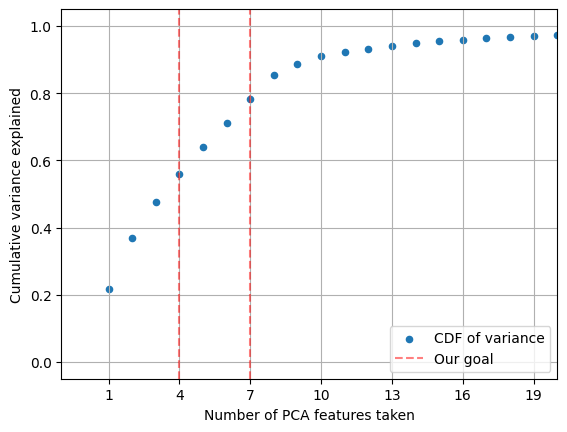

In [4]:
to_transform = df_features.drop(columns = ['Unnamed: 0','date_time','timestamp'])
pca = PCA(n_components = np.shape(to_transform)[1])
transformed = pca.fit_transform(to_transform.values)
cumulative_ratio = np.cumsum(pca.explained_variance_ratio_)

print('shape of input:',np.shape(to_transform))
plt.scatter(np.arange(1,len(cumulative_ratio)+1,1),cumulative_ratio, s = 20, label = 'CDF of variance')
plt.axvline(x = 4, color = 'red', ls = '--',label = 'Our goal', alpha = 0.5)
plt.axvline(x = 7, color = 'red', ls = '--', alpha = 0.5)
plt.xticks(np.arange(1,len(cumulative_ratio)+1,3))
plt.xlim(-1,20)
plt.ylim(-0.05,1.05)
plt.xlabel('Number of PCA features taken')
plt.ylabel('Cumulative variance explained')
plt.grid()
plt.legend()
plt.show()

### Setting up classes

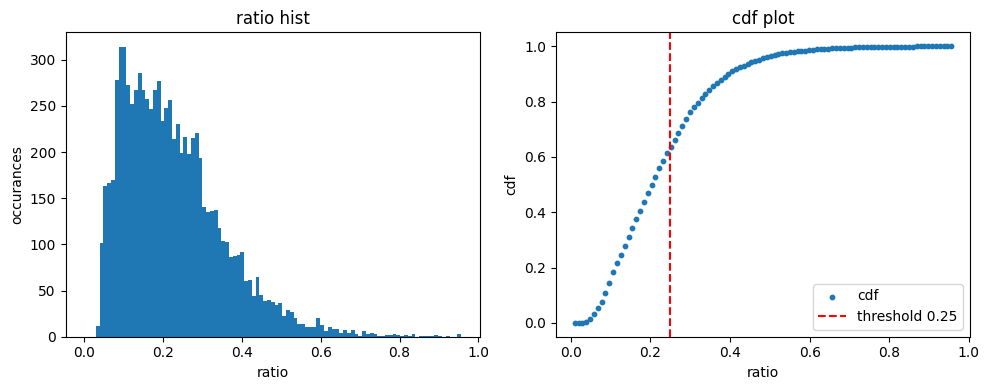

In [5]:
nbins = 100
thresholds = [0.25]

fig, ax = plt.subplots(1, 2, figsize=(10, 4)) 
hist = ax[0].hist(df_labels['ratio'], bins = np.linspace(0,max(df_labels['ratio']),nbins))
ax[0].set_xlabel('ratio')
ax[0].set_ylabel('occurances')
ax[0].set_title('ratio hist')

freq = hist[0]
cdf = np.cumsum(freq)
cdf = cdf / max(cdf)
x_axis = np.linspace(0,max(df_labels['ratio']),nbins)
x_axis = x_axis[1:]
ax[1].scatter(x_axis, cdf, s = 10, label = 'cdf')
ax[1].set_xlabel('ratio')
ax[1].set_ylabel('cdf')
ax[1].set_title('cdf plot')

for threshold in thresholds:
    ax[1].axvline(x=threshold, color='r', linestyle='--', label =f'threshold {threshold}')
ax[1].legend()

plt.tight_layout()
plt.show()

### Subdividing in classes

In [6]:
class_idx = 1
new_thresholds = [0] + thresholds + [max(df_labels['ratio'])]

df_labels['class'] = np.zeros(len(df_labels.index))

print('class intervals:',new_thresholds)
# Assign class based on interval
for i in range(len(new_thresholds) - 1):
    mask = (df_labels['ratio'] > new_thresholds[i]) & (df_labels['ratio'] <= new_thresholds[i + 1])
    df_labels.loc[mask, 'class'] = class_idx
    class_idx += 1

# Check number of datapoints in each class
all_classes = np.unique(df_labels['class'])
tot = len(df_labels['class'])

for class_ in all_classes:
    occ = np.sum(df_labels['class'] == class_)
    print(f'class {int(class_)} occurs {occ} times: {occ/tot:.2%}')


class intervals: [0, 0.25, 0.9559345076250148]
class 1 occurs 5267 times: 63.31%
class 2 occurs 3053 times: 36.69%


/tmp/ipykernel_11723/665116429.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_labels['class'] = np.zeros(len(df_labels.index))


In [7]:
# keeping only dayofthe year
df = df_features
features = ['day_sin_t0','day_cos_t0',
           'day_sin_t1','day_cos_t1',
           'day_sin_t2','day_cos_t2',
           'day_sin_t3','day_cos_t3',
           'day_sin_t4','day_cos_t4',
           'day_sin_t5','day_cos_t5',
           'day_sin_t6','day_cos_t6',
           'day_sin_t7','day_cos_t7',
           'day_sin_t8','day_cos_t8',
           'month_sin_t0','month_cos_t0',
           'month_sin_t1','month_cos_t1',
           'month_sin_t2','month_cos_t2',
           'month_sin_t3','month_cos_t3',
           'month_sin_t4','month_cos_t4',
           'month_sin_t5','month_cos_t5',
           'month_sin_t6','month_cos_t6',
           'month_sin_t7','month_cos_t7',
           'month_sin_t8','month_cos_t8']

# in alternative one can use the following lines to keep day and month
'''
features = ['sin_dayofyear_t0','cos_dayofyear_t0',
            'sin_dayofyear_t1','cos_dayofyear_t1',
            'sin_dayofyear_t2','cos_dayofyear_t2',
            'sin_dayofyear_t3','cos_dayofyear_t3',
            'sin_dayofyear_t4','cos_dayofyear_t4',
            'sin_dayofyear_t5','cos_dayofyear_t5',
            'sin_dayofyear_t6','cos_dayofyear_t6',
            'sin_dayofyear_t7','cos_dayofyear_t7',
            'sin_dayofyear_t8','cos_dayofyear_t8'
            ]
'''

df = df.drop(columns = features)
timestamp = pd.to_datetime(df['timestamp'])

timestamp_backup = timestamp.copy()

################################################
# SOFIA
# questo vettore (timestamp) è quello che puoi usare per colorare diversamente i punti secondo un certo criterio
# al momento sta usando i dati di produzione di noemi (quelli un po' scrausi)
# se vuoi vedere cosa succede per le diverse stagioni puoi provare a cambiare con queste righe:
#timestamp = timestamp.dt.hour
#timestamp = [1 if x in [1,2,3] else 2 if x in [4,5,6] else 3 if x in [7,8,9] else 4 if x in [10,11,12] for x in timestamp]

timestamp = df_labels['class']
# una volta che hai buttato dentro quello che vuoi fai andare il codice (se non va fai andare anche la cella
# sopra che c'è un drop qui)
##################################################
# to save indexes for plotting later
timestamp_tensor = torch.tensor(timestamp, dtype = torch.float32)  # Encodes strings to integers

df.drop('timestamp', axis=1, inplace=True)

print("Input Dataframe Dim:", df.shape)
df


Input Dataframe Dim: (8320, 92)


,Unnamed: 0,year_t0,2t_t0,solar_t0,tp_t0,ws_10m_t0,ws_100m_t0,hour_sin_t0,hour_cos_t0,sin_dayofyear_t0,...,2t_t8,solar_t8,tp_t8,ws_10m_t8,ws_100m_t8,hour_sin_t8,hour_cos_t8,sin_dayofyear_t8,cos_dayofyear_t8,date_time
0,0,-1.224855,-1.266622,-0.785197,-0.540314,-0.169929,0.237315,0.249009,1.890047,0.025562,...,-1.279364,-0.785204,-0.539696,-0.982129,-1.132097,-0.685682,1.408711,0.025586,1.291842,2022-01-01 00:00:00
1,1,-1.224855,-1.324489,-0.785197,-0.540314,-0.167036,0.001132,1.183829,1.408519,0.025562,...,-1.305169,-0.785204,-0.539696,-0.791966,-0.931334,0.249115,1.890286,0.050415,1.291222,2022-01-01 03:00:00
2,2,-1.224855,-1.363120,-0.691746,-0.543042,-0.218606,-0.093139,1.571044,0.246007,0.025562,...,-1.369257,-0.785204,-0.539696,-0.709343,-0.778698,1.183912,1.408711,0.050415,1.291222,2022-01-01 06:00:00
3,3,-1.224855,-1.091436,0.355950,-0.543042,-0.396948,-0.530006,1.183829,-0.916506,0.025562,...,-1.427837,-0.704916,-0.537695,-0.616626,-0.664870,1.571118,0.246088,0.050415,1.291222,2022-01-01 09:00:00
4,4,-1.224855,-0.496955,0.545301,-0.543042,-0.719834,-0.962998,0.249009,-1.398034,0.025562,...,-1.170501,0.196247,-0.537695,-0.573833,-0.452988,1.183912,-0.916535,0.050415,1.291222,2022-01-01 12:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8315,8315,1.224561,-0.453550,-0.478673,-0.546437,-1.220757,-1.408609,-0.685811,-0.916506,-0.024044,...,-0.518011,0.586399,-0.545575,-1.441098,-1.518295,0.249115,-1.398110,0.000749,1.292048,2024-12-30 15:00:00
8316,8316,1.224561,-1.110274,-0.785197,-0.545773,-1.125086,-1.549938,-1.073026,0.246007,-0.024044,...,-0.567924,-0.485478,-0.545575,-1.249467,-1.388240,-0.685682,-0.916535,0.000749,1.292048,2024-12-30 18:00:00
8317,8317,1.224561,-1.110274,-0.785197,-0.545773,-1.125086,-1.549938,-1.073026,0.246007,-0.024044,...,-1.247314,-0.785204,-0.544950,-1.301211,-1.439442,-1.072887,0.246088,0.000749,1.292048,2024-12-30 18:00:00
8318,8318,1.224561,-1.322641,-0.785197,-0.545773,-1.180936,-1.527834,-0.685811,1.408519,-0.024044,...,-1.247314,-0.785204,-0.544950,-1.301211,-1.439442,-1.072887,0.246088,0.000749,1.292048,2024-12-30 21:00:00


In [8]:
# Custom Dataset
class TabularDataset(torch.utils.data.Dataset):
  def __init__(self, data_tensor, timestamp_tensor):
    self.data = data_tensor
    self.timestamp = timestamp_tensor

  def __len__(self):
    return self.data.shape[0]

  def __getitem__(self, index):
    return self.data[index], self.timestamp[index], self.timestamp[index]                              # dummy label for compatibility

# Load and preprocess CSV data
#df = pd.read_csv("IT_NORD_VAE_input.csv")
#df.drop('timestamp', axis=1, inplace=True)
df = df.drop(columns = ['date_time','Unnamed: 0'])
features = df.columns
data_tensor = torch.tensor(df.values, dtype=torch.float32)

# Split the dataset into train, val, test
dataset = TabularDataset(data_tensor, timestamp_tensor)

total_size = len(dataset)
train_size = int(0.7 * total_size)                               # %70 training, %15 validation and %15 test
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size
# WE WILL EDIT TO KFOLD

# order preserving data split
from torch.utils.data import Subset

# Compute sizes
total_size = len(dataset)
train_end = int(train_size)
val_end = train_end + int(val_size)

# Create sequential indices
indices = list(range(total_size))

# Create subsets without shuffling
dataset = TabularDataset(data_tensor, timestamp_tensor)
train_dataset = Subset(dataset, indices[:train_end])
val_dataset = Subset(dataset, indices[train_end:val_end])
test_dataset = Subset(dataset, indices[val_end:])

print("Input Dataframe Dim:", df.shape)

Input Dataframe Dim: (8320, 90)


### Training 

## Grid search on hyperparameters space

In [9]:
def train_and_evaluate(hparams, DEVICE, INPUT_DIM, train_loader, val_loader,show_progress = True):
    # Parameters
    H_DIM = hparams['H_DIM']
    NUM_EPOCHS = hparams['NUM_EPOCHS']
    BATCH_SIZE = hparams['BATCH_SIZE']
    LR_RATE = hparams['LR_RATE']
    Z_DIM = hparams['Z_DIM']

    # Model
    model = VariationalAutoEncoder(
        INPUT_DIM,
        H_DIM,
        Z_DIM
    ).to(DEVICE)

    optimizer = optim.Adam(model.parameters(), lr=LR_RATE)
    loss_fn = nn.MSELoss(reduction='sum')

    # Training
    for epoch in range(NUM_EPOCHS):
        epoch_total = 0
        epoch_recon = 0
        epoch_kl = 0
        num_samples = 0

        model.train()
        loop = tqdm(train_loader, desc=f"Z_DIM = {Z_DIM} | Epoch {epoch+1}/{NUM_EPOCHS}", disable = not show_progress)

        for i, (x_batch, t, _) in enumerate(loop):
            x_batch = x_batch.to(DEVICE)
            x_reconstructed, mu, sigma = model(x_batch)

            # Loss
            reconstruction_loss = loss_fn(x_reconstructed, x_batch)
            logvar = torch.log(sigma.pow(2) + 1e-8)
            kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
            loss = reconstruction_loss + kl_div

            # Backprop
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loop.set_postfix(
                total_loss=loss.item() / x_batch.shape[0],
                reconstruction_loss=reconstruction_loss.item() / x_batch.shape[0],
                kl_div=kl_div.item() / x_batch.shape[0])

            epoch_total += loss.item()
            epoch_recon += reconstruction_loss.item()
            epoch_kl += kl_div.item()
            num_samples += x_batch.shape[0]

    train_loss = epoch_total / num_samples

    # Validation
    model.eval()
    val_total = 0
    val_recon = 0
    val_kl = 0
    val_samples = 0

    with torch.no_grad():
        for x_val, t, _ in val_loader:
            x_val = x_val.to(DEVICE)
            x_reconstructed, mu, sigma = model(x_val)
            reconstruction_loss = loss_fn(x_reconstructed, x_val)
            logvar = torch.log(sigma.pow(2) + 1e-8)
            kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
            loss = reconstruction_loss + kl_div

            val_total += loss.item()
            val_recon += reconstruction_loss.item()
            val_kl += kl_div.item()
            val_samples += x_val.size(0)

    val_loss = val_total / val_samples

    return {
        'train_loss': train_loss,
        'val_loss': val_loss,
        'Z_DIM': Z_DIM,
        'H_DIM': H_DIM,
        'LR_RATE': LR_RATE
    }


### Running grid search

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# parameters for grid search
param_grid = {
    'H_DIM': [16,32,48,64],
    'Z_DIM': [4,5],
    'LR_RATE': [1e-3,5e-3,1e-4,5e-4,1e-5],
    'BATCH_SIZE': [128,64],
    'NUM_EPOCHS': [25]
}
INPUT_DIM = data_tensor.shape[1]

# get their possible comb
keys, values = zip(*param_grid.items())
param_combinations = [dict(zip(keys, v)) for v in product(*values)]

best_loss = 1e10
best_params = None

for hparams in tqdm(param_combinations, desc="Grid Search"):
    
    BATCH_SIZE = hparams['BATCH_SIZE']
    train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True)
    val_loader = DataLoader(val_dataset, batch_size = BATCH_SIZE)
    test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE)
    
    out = train_and_evaluate(hparams, device, INPUT_DIM, train_loader, val_loader, show_progress = False)
    train_loss = out['train_loss']
    val_loss = out['val_loss']
    
    if val_loss < best_loss:
        best_loss = val_loss
        best_params = hparams
        print('current lowest validation loss:', val_loss)
        print(f'best params:{best_params} \n')

print("\nBest loss:", best_loss)
print("Best Params:", best_params)

Grid Search:   0%|          | 0/80 [00:00<?, ?it/s]

current lowest validation loss: 63.56405561398237
best params:{'H_DIM': 16, 'Z_DIM': 4, 'LR_RATE': 0.001, 'BATCH_SIZE': 128, 'NUM_EPOCHS': 25} 

current lowest validation loss: 63.53399716890775
best params:{'H_DIM': 16, 'Z_DIM': 4, 'LR_RATE': 0.001, 'BATCH_SIZE': 64, 'NUM_EPOCHS': 25} 

current lowest validation loss: 53.64891169621394
best params:{'H_DIM': 16, 'Z_DIM': 4, 'LR_RATE': 0.005, 'BATCH_SIZE': 128, 'NUM_EPOCHS': 25} 

current lowest validation loss: 44.56320346930088
best params:{'H_DIM': 16, 'Z_DIM': 5, 'LR_RATE': 0.005, 'BATCH_SIZE': 128, 'NUM_EPOCHS': 25} 

current lowest validation loss: 42.37761556185209
best params:{'H_DIM': 32, 'Z_DIM': 5, 'LR_RATE': 0.005, 'BATCH_SIZE': 64, 'NUM_EPOCHS': 25} 

current lowest validation loss: 39.17643424792168
best params:{'H_DIM': 64, 'Z_DIM': 5, 'LR_RATE': 0.005, 'BATCH_SIZE': 128, 'NUM_EPOCHS': 25} 


Best loss: 39.17643424792168
Best Params: {'H_DIM': 64, 'Z_DIM': 5, 'LR_RATE': 0.005, 'BATCH_SIZE': 128, 'NUM_EPOCHS': 25}


# Training on best params


In [12]:

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

INPUT_DIM = data_tensor.shape[1]
H_DIM = best_params['H_DIM']
NUM_EPOCHS = best_params['NUM_EPOCHS'] + 150 # train for lots of epochs
BATCH_SIZE = best_params['BATCH_SIZE']
LR_RATE = best_params['LR_RATE'] * 0.1
Z_DIM = best_params['Z_DIM']

all_histories = {}

train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE)

print(f"\nTraining with Z_DIM = {Z_DIM}")
model = VariationalAutoEncoder(INPUT_DIM, H_DIM, Z_DIM).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR_RATE)
loss_fn = nn.MSELoss(reduction="sum")

history = {
      'total_loss': [],
      'reconstruction_loss': [],
      'kl_div': [],
      'val_total_loss': [],
      'val_reconstruction_loss': [],
      'val_kl_div': [],
      'test_loss': None
}
outputs = []
epoch_bar = tqdm(range(NUM_EPOCHS), desc=f"Training Z_DIM = {Z_DIM}")

for epoch in epoch_bar:
    epoch_total = 0
    epoch_recon = 0
    epoch_kl = 0
    num_samples = 0

    model.train()
    
    # Optional: disable or remove batch-level tqdm to reduce clutter
    for i, (x_batch, t, _) in enumerate(train_loader):  # removed inner tqdm here
        #print("Labels in batch:", t)
        x_batch = x_batch.to(DEVICE)
        x_reconstructed, mu, sigma = model(x_batch)

        # Loss Function
        reconstruction_loss = loss_fn(x_reconstructed, x_batch)
        logvar = torch.log(sigma.pow(2) + 1e-8)
        kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = reconstruction_loss + kl_div

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_total += loss.item()
        epoch_recon += reconstruction_loss.item()
        epoch_kl += kl_div.item()
        num_samples += x_batch.shape[0]

        if i == 0:
            outputs.append((epoch, x_batch.clone(), x_reconstructed.clone()))

    # Store epoch losses
    history['total_loss'].append(epoch_total / num_samples)
    history['reconstruction_loss'].append(epoch_recon / num_samples)
    history['kl_div'].append(epoch_kl / num_samples)

    # Validation step
    model.eval()
    val_total = 0
    val_recon = 0
    val_kl = 0
    val_samples = 0

    with torch.no_grad():
        for x_val, t, _ in val_loader:
            x_val = x_val.to(DEVICE)
            x_reconstructed, mu, sigma = model(x_val)
            loss_rec = loss_fn(x_reconstructed, x_val)
            logvar = torch.log(sigma.pow(2) + 1e-8)
            kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
            loss = loss_rec + kl_div

            val_total += loss.item()
            val_recon += loss_rec.item()
            val_kl += kl_div.item()
            val_samples += x_val.size(0)

    history['val_total_loss'].append(val_total / val_samples)
    history['val_reconstruction_loss'].append(val_recon / val_samples)
    history['val_kl_div'].append(val_kl / val_samples)

    # Update the epoch progress bar with losses info
    epoch_bar.set_postfix({
        "Train Loss": f"{history['total_loss'][-1]:.4f}",
        "Val Loss": f"{history['val_total_loss'][-1]:.4f}"
    })



Training with Z_DIM = 5


Training Z_DIM = 5:   0%|          | 0/175 [00:00<?, ?it/s]

# Attempt to use PCA for representing hidden space

explained variance: [0.24709749 0.22082055 0.18857004 0.17356925 0.16994272]
(8320, 5)


<Figure size 750x500 with 0 Axes>

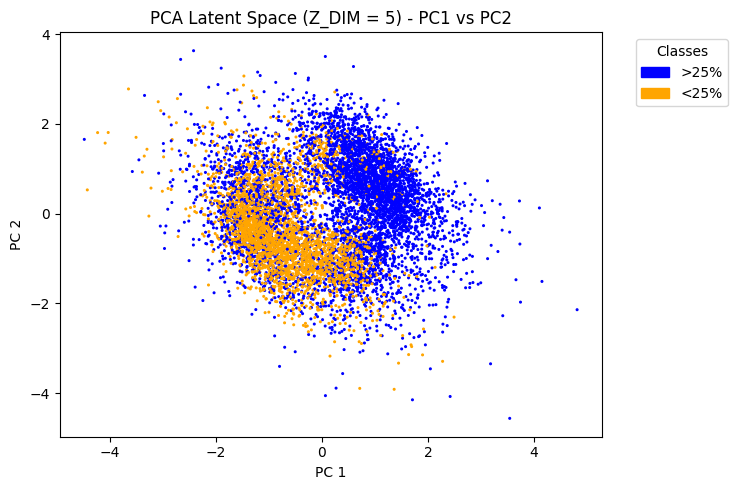

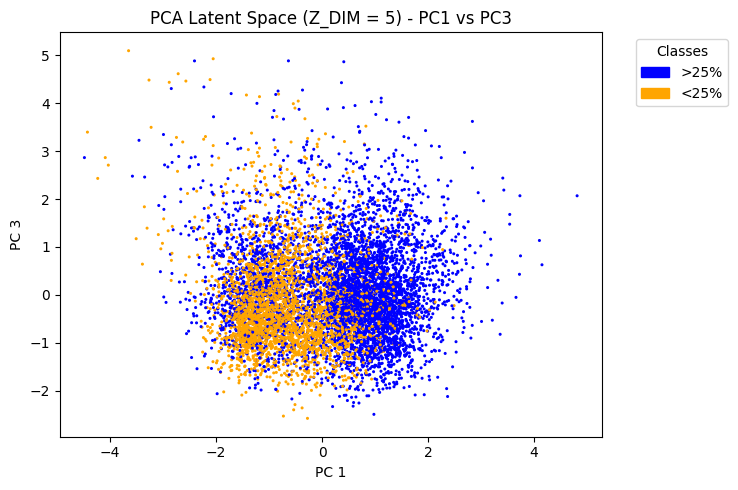

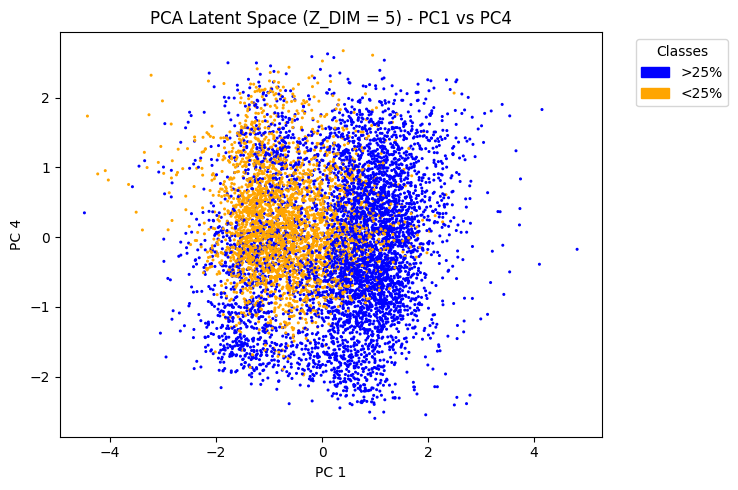

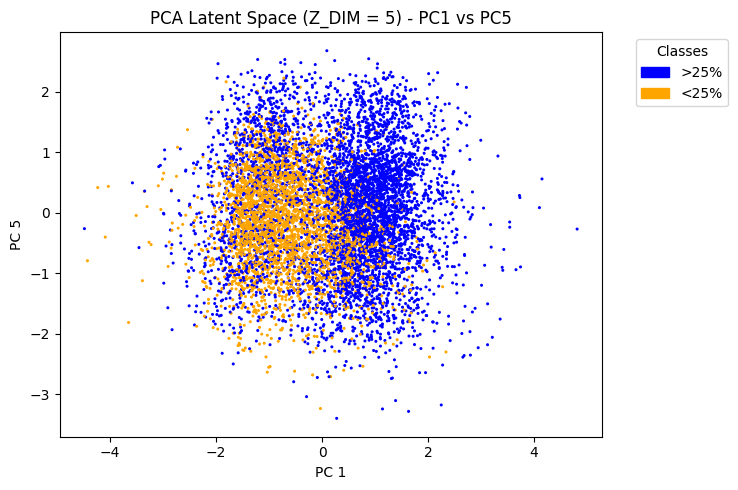

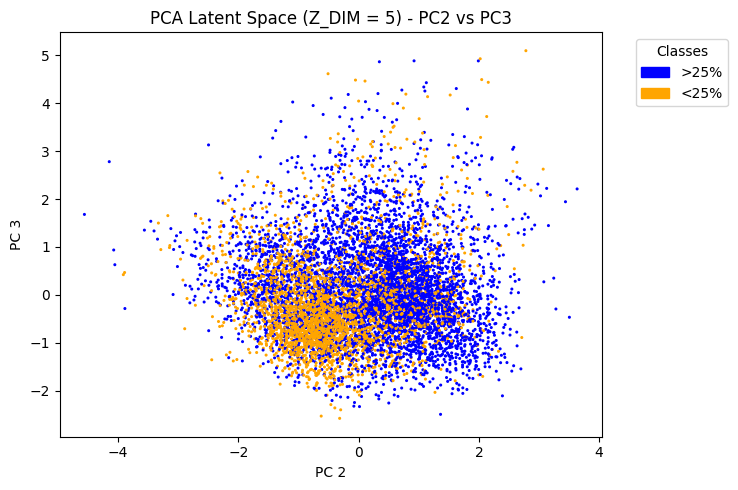

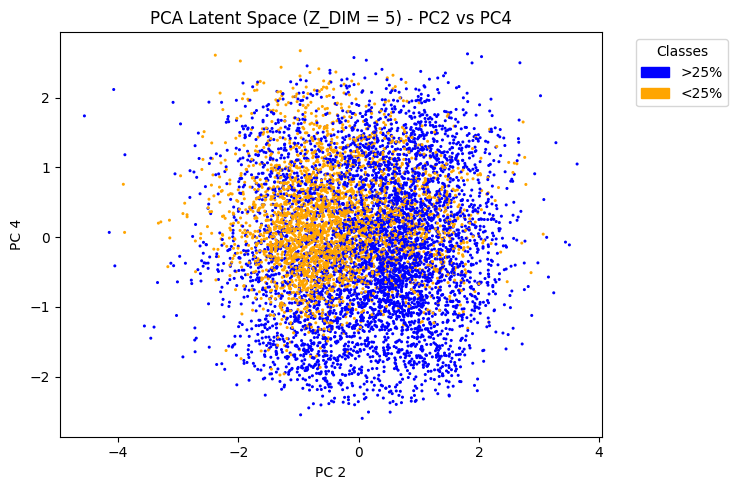

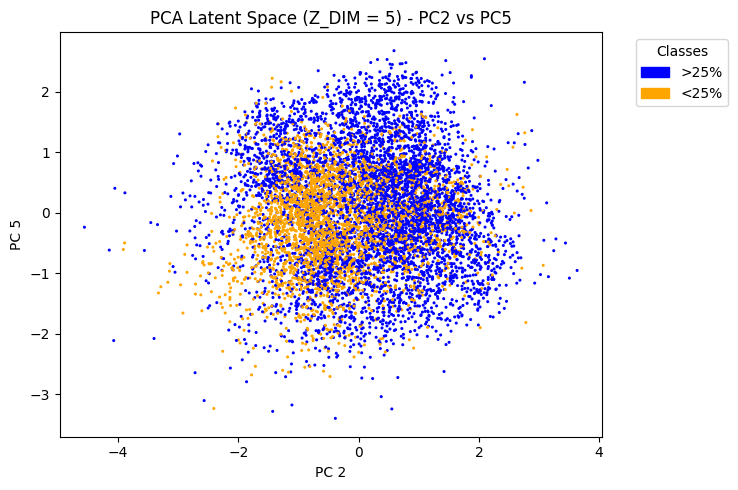

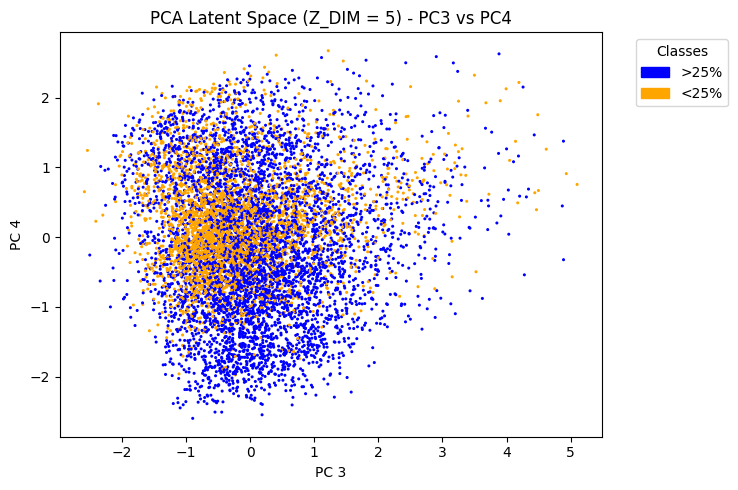

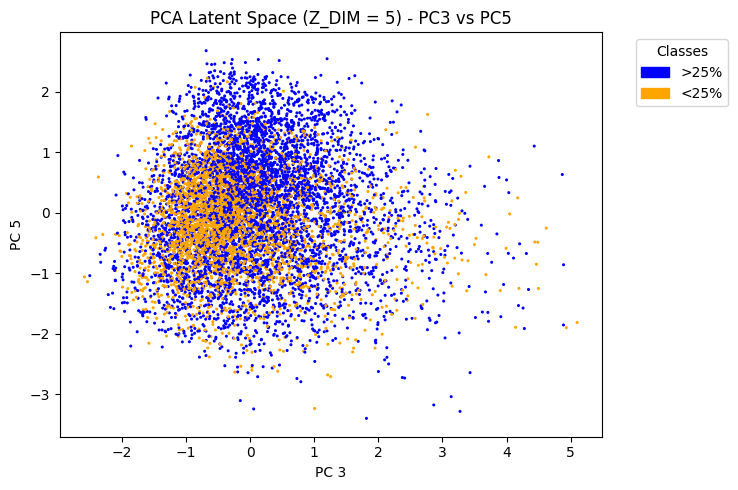

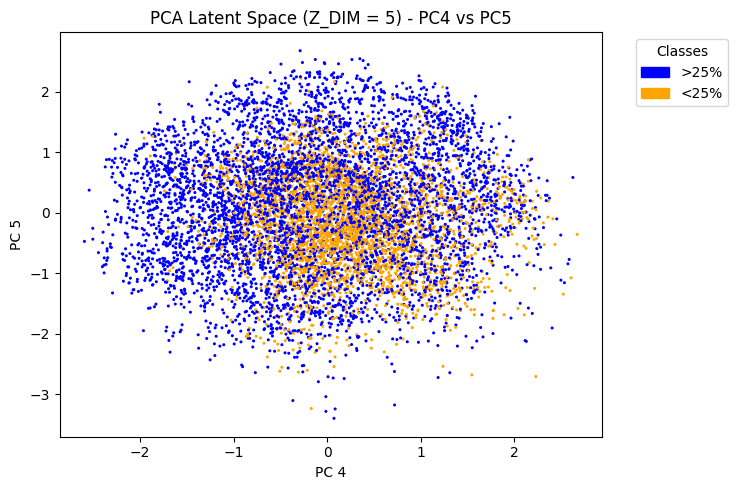

In [13]:

from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
import itertools

# get the latent vectors (test set)
zs = []
ts = []
reconstructed = []
original = []

model.eval()
with torch.no_grad():
    # train set
    for x_train, t, _ in train_loader:
        x_train = x_train.to(DEVICE)
        x_reconstructed, mu, sigma = model(x_train)
        epsilon = torch.randn_like(sigma)
        
        # compute z via reparameterization trick
        z = mu + sigma * epsilon
        zs.append(z.cpu())  # vector
        ts.append(t)  # class information
        original.append(x_train.cpu().numpy())
        reconstructed.append(x_reconstructed.cpu().numpy())
        
    # validation set
    for x_val, t, _ in val_loader:
        x_val = x_val.to(DEVICE)
        x_reconstructed, mu, sigma = model(x_val)
        epsilon = torch.randn_like(sigma)
        
        # compute z via reparameterization trick
        z = mu + sigma * epsilon
        zs.append(z.cpu())  # vector
        ts.append(t)  # class information
        original.append(x_val.cpu().numpy())
        reconstructed.append(x_reconstructed.cpu().numpy())

    # test set
    for x_test, t, _ in test_loader:
        x_test = x_test.to(DEVICE)
        x_reconstructed, mu, sigma = model(x_test)
        epsilon = torch.randn_like(sigma)
        
        # compute z via reparameterization trick
        z = mu + sigma * epsilon
        zs.append(z.cpu())  # vector
        ts.append(t)  # class information
        original.append(x_test.cpu().numpy())
        reconstructed.append(x_reconstructed.cpu().numpy())

zs = torch.cat(zs, dim=0)  # (total_samples, latent_dim)
zs = zs.numpy()          # convert to numpy array
ts = torch.cat(ts, dim=0)
ts = ts.numpy()

pca = PCA(n_components = best_params['Z_DIM'])
zs_pca = pca.fit_transform(zs)
print('explained variance:',pca.explained_variance_ratio_)

print(np.shape(zs_pca))
plt.figure(figsize = (7.5, 5))


############################
# SOFIA
# qui ci sono un paio di cose che dovresti ritoccare per i plot
# colors handling
unique_ts = np.unique(ts)
# vengono usati solo i primi n colori (dove n numero di diverse categorie in timestamp
custom_colors = ['blue','orange', 'green','#006064','lightblue','#1B5E20', 'green', 'brown','orange','yellow','pink','red','#FFEB3B','#FAF4C4','#FAF4C4',]  
keep_colors = custom_colors[:len(unique_ts)]
custom_colormap = ListedColormap(custom_colors[:len(unique_ts)])
# legend
# qui dovresti scrivere a mano a che cosa corrisponde ogni categoria
# custom_labels = ['winter','spring','summer','autumn']
custom_labels = ['>25%',
                 '<25%']
#############################
legend_handles = [
    Patch(color=keep_colors[i], label=custom_labels[i]) for i in range(len(unique_ts))
]

# Plot all 2D combinations of PCA components
combinations = list(itertools.combinations(range(zs_pca.shape[1]), 2))
for i, (x_idx, y_idx) in enumerate(combinations):
    plt.figure(figsize=(7.5, 5))
    
    scatter = plt.scatter(zs_pca[:, x_idx], zs_pca[:, y_idx], c=ts, cmap=custom_colormap, s=1.4)
    
    plt.title(f"PCA Latent Space (Z_DIM = {Z_DIM}) - PC{x_idx+1} vs PC{y_idx+1}")
    plt.xlabel(f"PC {x_idx+1}")
    plt.ylabel(f"PC {y_idx+1}")
    
    plt.legend(handles=legend_handles, title="Classes", bbox_to_anchor=(1.05, 1), loc='upper left')
    #plt.colorbar(label='Generation trend')
    plt.tight_layout()
    plt.savefig(f"PCA_output/ZDIM_{Z_DIM}_PC{x_idx}_{y_idx}.png")
    plt.show()

### Compute average losses

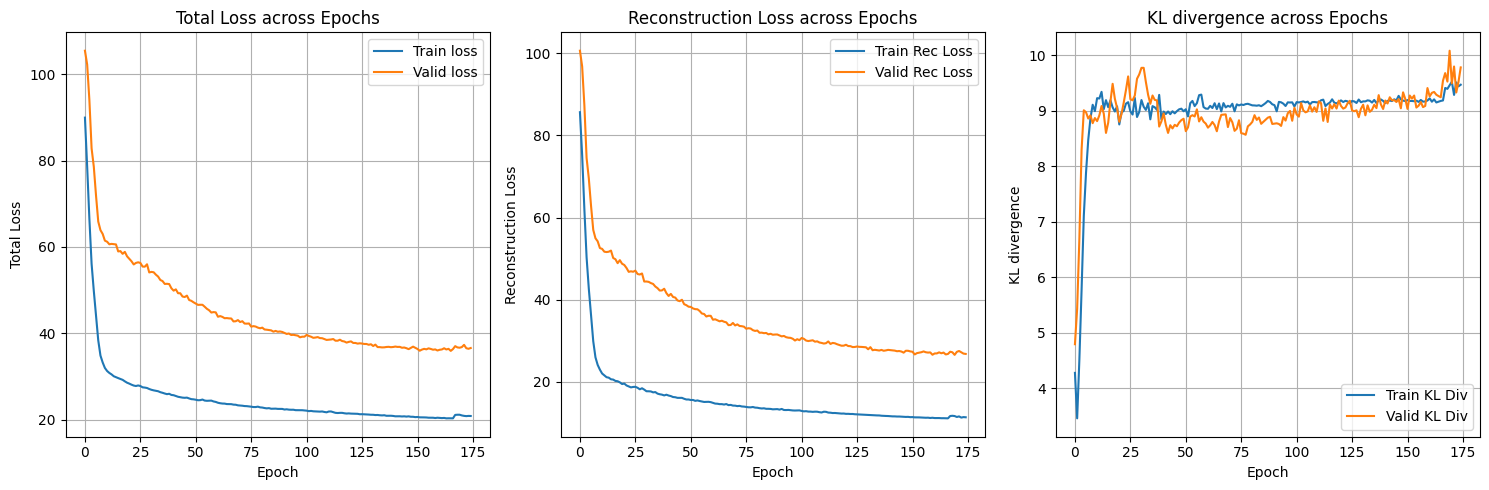

In [14]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharex=False)
ymin, ymax = 0, 140

epochs = np.arange(0,NUM_EPOCHS ,1)
# Plot of Total Loss
axs[0].plot(epochs,history['total_loss'], label = 'Train loss')
axs[0].plot(epochs,history['val_total_loss'], label = 'Valid loss')
axs[0].set_ylabel("Total Loss")
axs[0].set_xlabel("Epoch")
axs[0].set_title("Total Loss across Epochs")
axs[0].legend()
axs[0].grid(True)

# Plot of Reconstruction Loss
axs[1].plot(epochs,history['reconstruction_loss'], label = 'Train Rec Loss')
axs[1].plot(epochs,history['val_reconstruction_loss'], label = 'Valid Rec Loss')
axs[1].set_ylabel("Reconstruction Loss")
axs[1].set_xlabel("Epoch")
axs[1].set_title("Reconstruction Loss across Epochs")
axs[1].legend()
axs[1].grid(True)

# Plot of KL Divergence
axs[2].plot(epochs,history['kl_div'], label = 'Train KL Div')
axs[2].plot(epochs,history['val_kl_div'], label = 'Valid KL Div')
axs[2].set_ylabel("KL divergence")
axs[2].set_xlabel("Epoch")
axs[2].set_title("KL divergence across Epochs")
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

### Reconstruct the input

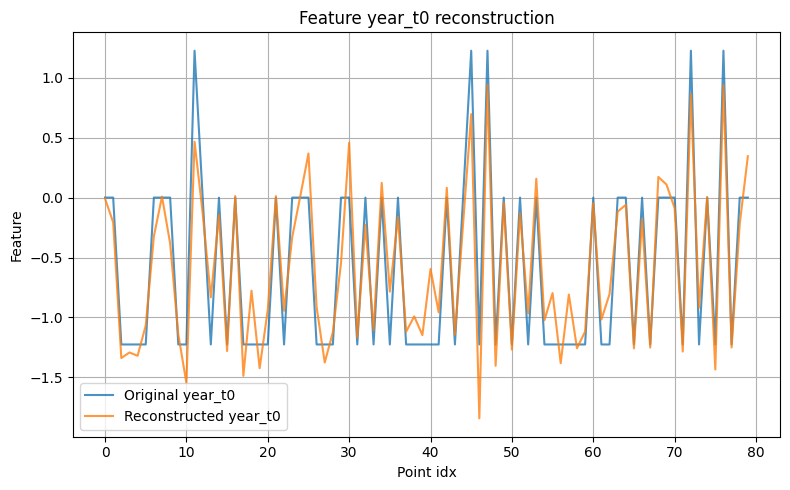

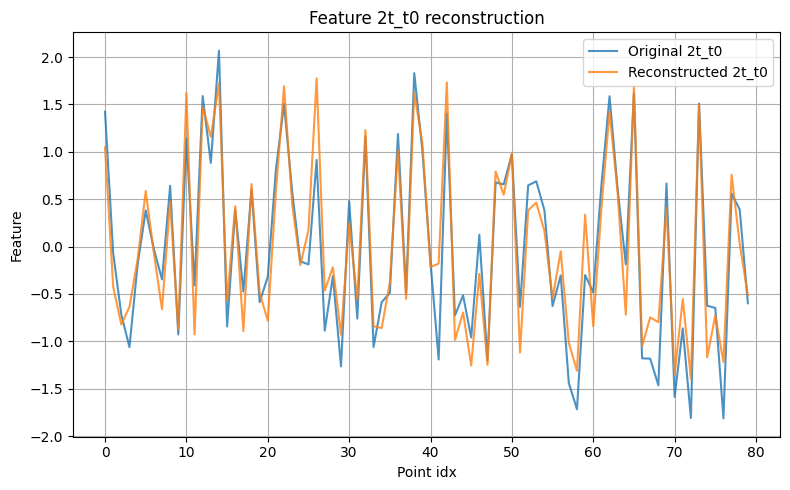

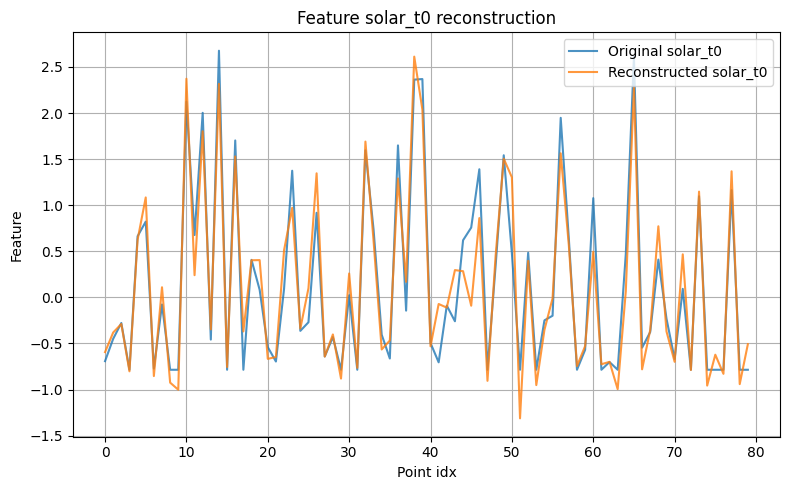

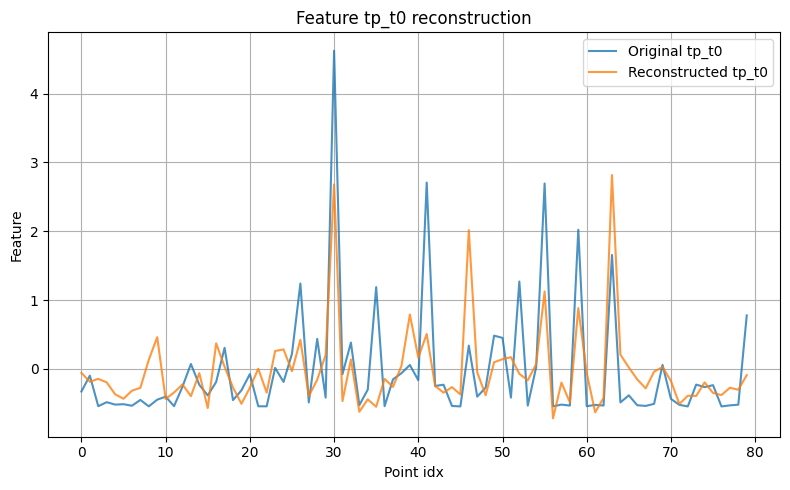

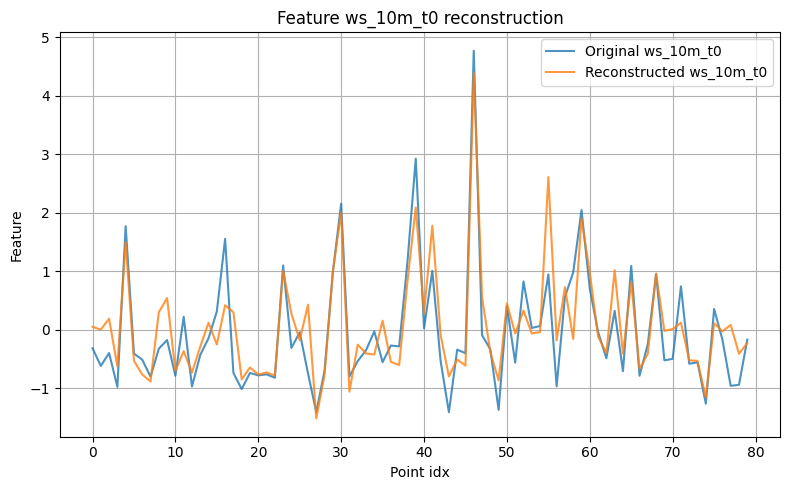

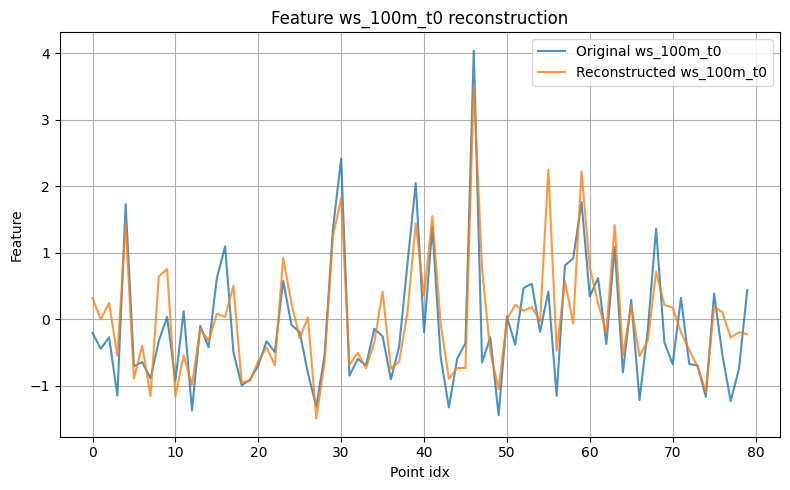

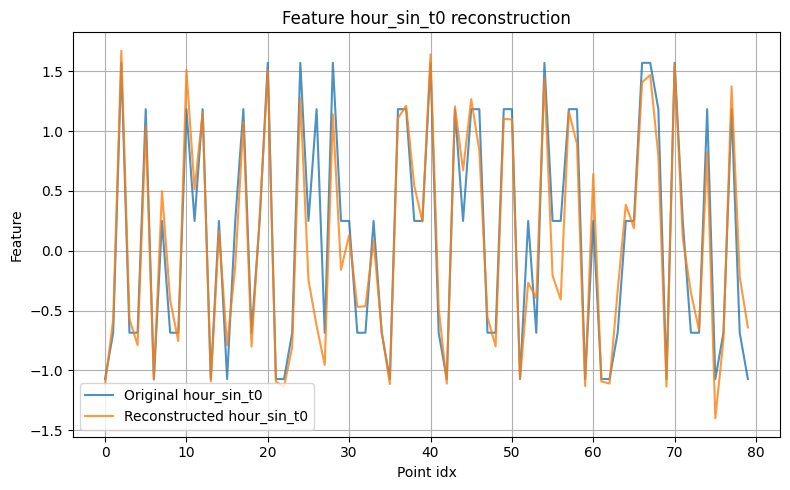

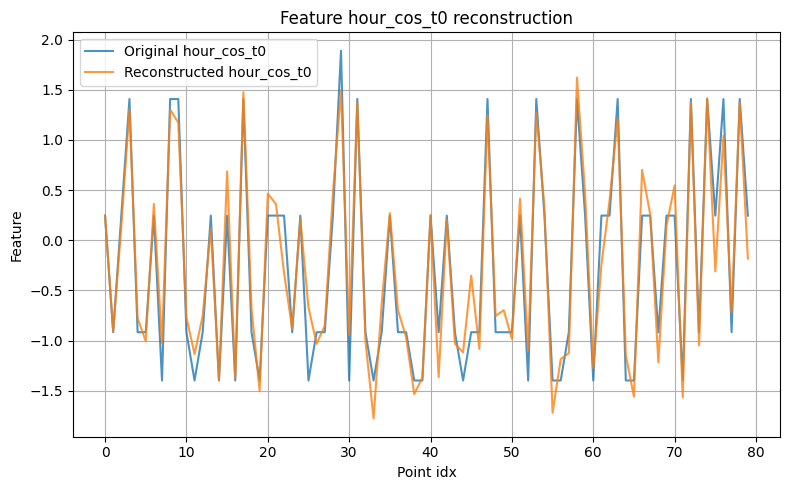

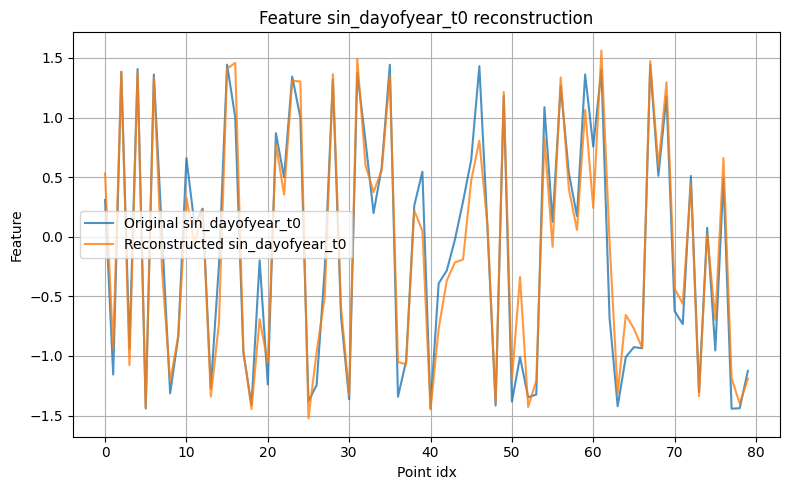

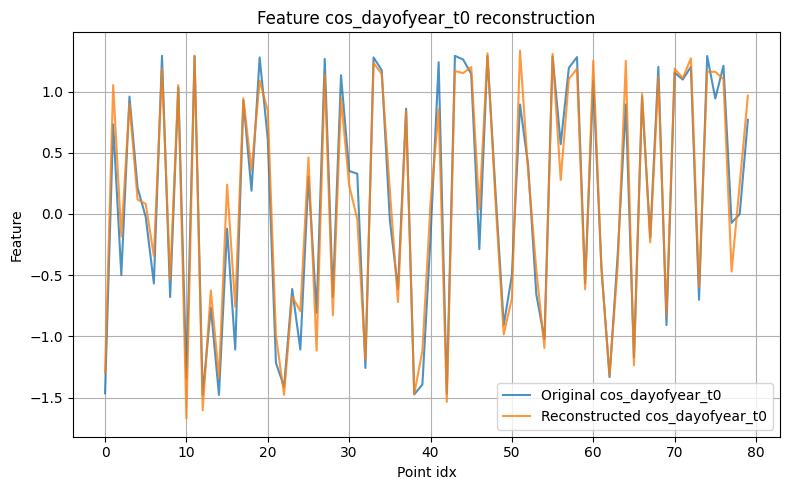

In [15]:
# concatenate all batches
original_all = np.concatenate(original, axis=0)       
reconstructed_all = np.concatenate(reconstructed, axis=0)
#print(np.shape(original_all),np.shape(reconstructed_all))
features_to_plot = [0,1,2,3,4,5,6,7,8,9]
dummy_x = np.arange(0,np.shape(original_all)[0],1)
points_to_plot = 80

for feature_idx in features_to_plot:
    
    plt.figure(figsize=(8, 5))
    plt.plot(dummy_x[:points_to_plot],
                original_all[:, feature_idx][:points_to_plot],
                alpha=0.8, label=f'Original {features[feature_idx]}')
    plt.plot(dummy_x[:points_to_plot],
                reconstructed_all[:, feature_idx][:points_to_plot],
                alpha=0.8, label=f'Reconstructed {features[feature_idx]}')
    plt.xlabel("Point idx")
    plt.ylabel("Feature")
    plt.title(f"Feature {features[feature_idx]} reconstruction")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"feature_reconstruction/feature_{feature_idx}_reconstruction.png")
    plt.show() 

# Attack a NN in tail

### Model

In [16]:
class SimpleClassifier(nn.Module):
    def __init__(self, z_dim, x_extra_dim, hidden_dims, output_dim, dropout_prob = 0.3):
        super(SimpleClassifier, self).__init__()
        input_dim = z_dim + x_extra_dim

        self.fc1 = nn.Linear(input_dim, hidden_dims[0])
        self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.output = nn.Linear(hidden_dims[1], output_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout_prob) 

    def forward(self, zs, x_extra):
        #print('zs:', zs.shape, 'x_extra:', x_extra.shape)

        x = torch.cat((zs, x_extra), dim=1)  # concatenate along feature dimension
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        logits = self.output(x)
        return logits

### Data preparation

In [17]:
class CombinedDataset(Dataset):
    def __init__(self, zs_tensor, X_extra, Y):
        self.zs = zs_tensor
        self.X_extra = X_extra
        self.Y = Y

    def __len__(self):
        return len(self.Y)

    def __getitem__(self, idx):
        return self.zs[idx], self.X_extra[idx], self.Y[idx]

In [18]:
# compute all hidden vectors

model.eval()  # set to evaluation mode
device = 'cpu'
data_tensor = data_tensor.to(device)  # move input to same device as model

with torch.no_grad():
    mu, logvar = model.encode(data_tensor)
    zs = mu.cpu().numpy()

print(np.shape(zs))
hidden_vectors = zs


(8320, 5)


In [19]:
print(np.shape(df_labels))

(8320, 7)


### Rescale hidden vectors and extra inputs

In [20]:
from sklearn.preprocessing import StandardScaler
scaler_z = StandardScaler()
scaler_z.fit(zs)

scaled_zs = scaler_z.transform(zs)

scaler_X = StandardScaler()
scaler_X.fit(df_labels.drop(columns=['class','date_time','ratio']).values)
X_scaled = scaler_X.transform(df_labels.drop(columns=['class','date_time','ratio']).values)

                              

In [21]:
# zs are the latent space resulting vectors
# we need to attach to them the corresponding labels

X_extra = torch.tensor(X_scaled, dtype=torch.float32)  # replace 'label' with your actual label column
Y = torch.tensor(df_labels['class'].values, dtype=torch.long)  # or float if regression
print(torch.unique(Y))


if isinstance(zs, np.ndarray):
    zs_tensor = torch.tensor(scaled_zs, dtype=torch.float32)
else:
    zs_tensor = scaled_zs  # already a tensor

full_dataset = CombinedDataset(zs_tensor, X_extra, Y)

indices = list(range(total_size))

train_dataset = Subset(full_dataset, indices[:train_end])
val_dataset = Subset(full_dataset, indices[train_end:val_end])
test_dataset = Subset(full_dataset, indices[val_end:])

print('zs_tensor shape:', zs_tensor.shape)       # e.g. (N, z_dim)
print('X_extra shape:', X_extra.shape)     

z_dim = zs_tensor.shape[1]
x_extra_dim = X_extra.shape[1]

tensor([1, 2])
zs_tensor shape: torch.Size([8320, 5])
X_extra shape: torch.Size([8320, 4])


### Training the NN

In [23]:
device = 'cpu'

num_epochs = 50
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Define the search space
param_grid = {
    'hidden_dims': [[64, 32], [32,16]],
    'lr': [1e-4, 1e-3],
    'batch_size': [64, 128],
    'weight_decay': [1e-2,1e-3,1e-4],
    'dropout_prob': [0.05,0.15,0.3] 
}

# Create all combinations of parameters
param_combinations = list(product(*param_grid.values()))

correct = 0
total = 0
# Best tracking
best_val_accuracy = 0.0
best_model = None
best_params = None

# Grid search loop
for params in tqdm(param_combinations, desc="Grid Search"):
    hidden_dims, lr, batch_size, weight_decay, dropout_prob = params
    print(f"\nTraining with: hidden_dims={hidden_dims}, lr={lr}, batch_size={batch_size}, weight_decay={weight_decay}")

    # Update loaders with batch size
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Initialize model, loss, optimizer
    modelNN = SimpleClassifier(z_dim = z_dim,
                               x_extra_dim = x_extra_dim,
                               hidden_dims=hidden_dims,
                               output_dim=len(torch.unique(Y))+1,
                               dropout_prob=dropout_prob
                              ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(modelNN.parameters(), lr=lr, weight_decay = weight_decay)

    # Training
    for epoch in range(num_epochs):
        modelNN.train()
        for zs, x_extra, labels in train_loader:
            zs, x_extra, labels = zs.to(device), x_extra.to(device), labels.to(device)

            optimizer.zero_grad()
            logits = modelNN(zs, x_extra)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

    # Validation
    modelNN.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for zs, x_extra, labels in val_loader:
            zs, x_extra, labels = zs.to(device), x_extra.to(device), labels.to(device)
            logits = modelNN(zs, x_extra)
            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = 100 * correct / total
    print(f"Validation Accuracy: {val_accuracy:.2f}%")

    # Save best
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_model = modelNN
        best_params = {
            'hidden_dims': hidden_dims,
            'lr': lr,
            'batch_size': batch_size,
            'weight_decay': weight_decay,
            'dropout_prob': dropout_prob
        }

print("\nBest Hyperparameters:")
print(best_params)
print(f"Best Validation Accuracy: {best_val_accuracy:.2f}%")


Grid Search:   0%|          | 0/72 [00:00<?, ?it/s]


Training with: hidden_dims=[64, 32], lr=0.0001, batch_size=64, weight_decay=0.01
Validation Accuracy: 86.46%

Training with: hidden_dims=[64, 32], lr=0.0001, batch_size=64, weight_decay=0.01
Validation Accuracy: 88.54%

Training with: hidden_dims=[64, 32], lr=0.0001, batch_size=64, weight_decay=0.01
Validation Accuracy: 90.06%

Training with: hidden_dims=[64, 32], lr=0.0001, batch_size=64, weight_decay=0.001
Validation Accuracy: 88.46%

Training with: hidden_dims=[64, 32], lr=0.0001, batch_size=64, weight_decay=0.001
Validation Accuracy: 87.82%

Training with: hidden_dims=[64, 32], lr=0.0001, batch_size=64, weight_decay=0.001
Validation Accuracy: 90.54%

Training with: hidden_dims=[64, 32], lr=0.0001, batch_size=64, weight_decay=0.0001
Validation Accuracy: 88.78%

Training with: hidden_dims=[64, 32], lr=0.0001, batch_size=64, weight_decay=0.0001
Validation Accuracy: 89.74%

Training with: hidden_dims=[64, 32], lr=0.0001, batch_size=64, weight_decay=0.0001
Validation Accuracy: 90.79%



## Retraining with best params

Training Epochs:   0%|          | 0/40 [00:00<?, ?it/s]


Final Validation Accuracy: 91.67%


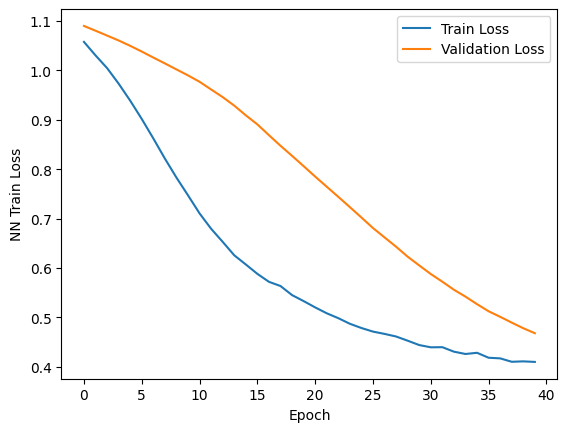

In [45]:
num_epochs = 40
hidden_dims = best_params['hidden_dims']
lr = best_params['lr']
batch_size = best_params['batch_size']
weight_decay = best_params['weight_decay']
dropout_prob = best_params['dropout_prob']

modelNN = SimpleClassifier(
    z_dim=z_dim,
    x_extra_dim=x_extra_dim,
    hidden_dims=hidden_dims,
    output_dim=len(torch.unique(Y)) + 1
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelNN.parameters(), lr=lr)

# Update loaders with batch size
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

NNlosses = []
val_losses = []

epoch_bar = tqdm(range(num_epochs), desc="Training Epochs")

for epoch in epoch_bar:
    modelNN.train()
    epoch_loss = 0.0

    for zs, x_extra, labels in train_loader:
        zs, x_extra, labels = zs.to(device), x_extra.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = modelNN(zs, x_extra)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * zs.size(0)

    avg_train_loss = epoch_loss / len(train_loader.dataset)
    NNlosses.append(avg_train_loss)

    # Validation loss
    modelNN.eval()
    val_loss = 0.0
    correct, total = 0, 0

    with torch.no_grad():
        for zs, x_extra, labels in val_loader:
            zs, x_extra, labels = zs.to(device), x_extra.to(device), labels.to(device)
            logits = modelNN(zs, x_extra)
            loss = criterion(logits, labels)

            val_loss += loss.item() * zs.size(0)
            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader.dataset)
    val_losses.append(avg_val_loss)

    val_accuracy = 100 * correct / total
    epoch_bar.set_postfix(train_loss=avg_train_loss, val_loss=avg_val_loss, val_acc=val_accuracy)

print(f"\nFinal Validation Accuracy: {val_accuracy:.2f}%")

plt.plot(np.arange(0,num_epochs,1),NNlosses, label = 'Train Loss')
plt.plot(np.arange(0,num_epochs,1),val_losses, label = 'Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('NN Train Loss')
plt.legend()
plt.show()

# Final results visualization 

### Performance on training set

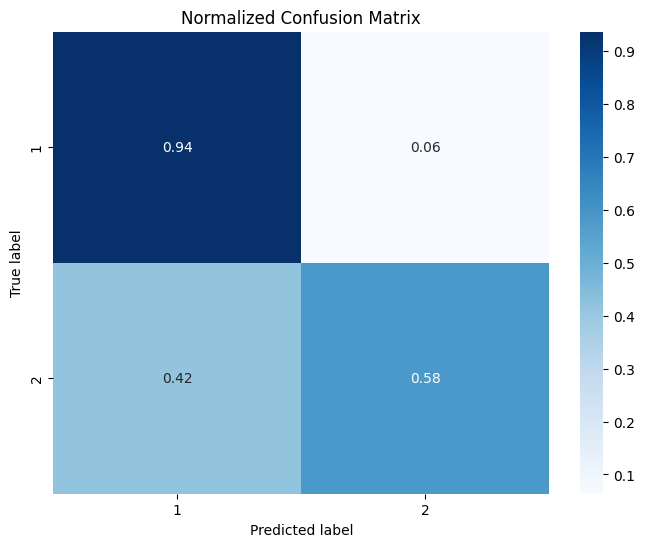

              precision    recall  f1-score   support

           1       0.86      0.94      0.90      4294
           2       0.77      0.58      0.66      1530

    accuracy                           0.84      5824
   macro avg       0.81      0.76      0.78      5824
weighted avg       0.84      0.84      0.84      5824



In [46]:
modelNN.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for zs, x_extra, labels in train_loader:
        zs, x_extra, labels = zs.to(device), x_extra.to(device), labels.to(device)
        logits = modelNN(zs, x_extra)
        _, predicted = torch.max(logits.data, 1)
        probs = torch.softmax(logits, dim=1)[:, 1]
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8,6))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap='Blues', xticklabels=[1, 2], yticklabels=[1, 2])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Normalized Confusion Matrix')
plt.show()

print(classification_report(all_labels, all_preds))

### Performance on validation set

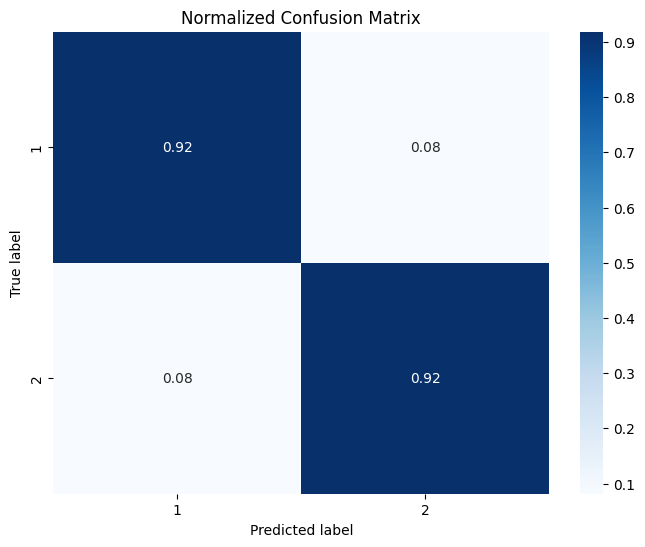

              precision    recall  f1-score   support

           1       0.84      0.92      0.88       404
           2       0.96      0.92      0.94       844

    accuracy                           0.92      1248
   macro avg       0.90      0.92      0.91      1248
weighted avg       0.92      0.92      0.92      1248



In [47]:
modelNN.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for zs, x_extra, labels in val_loader:
        zs, x_extra, labels = zs.to(device), x_extra.to(device), labels.to(device)
        logits = modelNN(zs, x_extra)
        _, predicted = torch.max(logits.data, 1)
        probs = torch.softmax(logits, dim=1)[:, 1]
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8,6))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap='Blues', xticklabels=[1, 2], yticklabels=[1, 2])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Normalized Confusion Matrix')
plt.show()

print(classification_report(all_labels, all_preds))

### Performance on test set

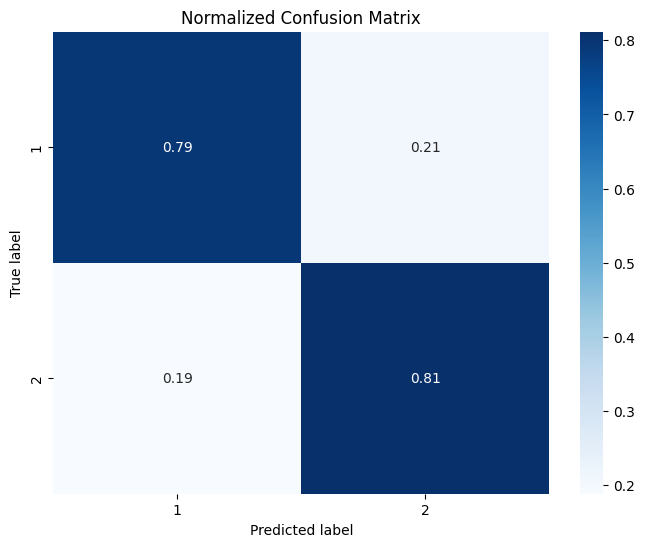

              precision    recall  f1-score   support

           1       0.78      0.79      0.79       569
           2       0.82      0.81      0.82       679

    accuracy                           0.80      1248
   macro avg       0.80      0.80      0.80      1248
weighted avg       0.80      0.80      0.80      1248



In [48]:
modelNN.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for zs, x_extra, labels in test_loader:
        zs, x_extra, labels = zs.to(device), x_extra.to(device), labels.to(device)
        logits = modelNN(zs, x_extra)
        _, predicted = torch.max(logits.data, 1)
        probs = torch.softmax(logits, dim=1)[:, 1]
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8,6))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap='Blues', xticklabels=[1, 2], yticklabels=[1, 2])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Normalized Confusion Matrix')
plt.show()

print(classification_report(all_labels, all_preds))

## ROC curve

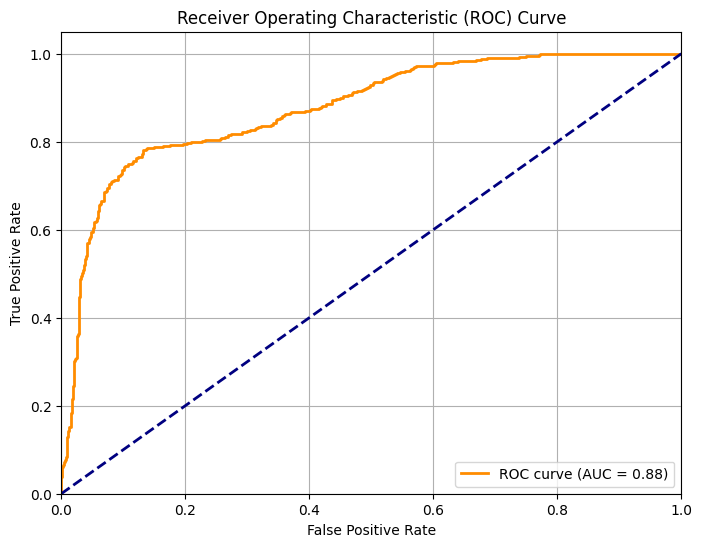

In [49]:
fpr, tpr, thresholds = roc_curve(all_labels, all_probs, pos_label=1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# Investigating the underperformance of test set

In [50]:
train_features = df_features[:train_end]
train_labels = df_labels[:train_end]
val_features = df_features[train_end:val_end]
val_labels = df_labels[train_end:val_end]
test_features = df_features[val_end:]
test_labels = df_labels[val_end:]


In [51]:
sel_columns = ['year_t0','2t_t0','solar_t0','tp_t0','ws_10m_t0','ws_100m_t0','sin_dayofyear_t0','cos_dayofyear_t0']
train_features = train_features[sel_columns]
test_features = test_features[sel_columns]
val_features = val_features[sel_columns]


In [52]:
summary_train = train_features.describe().T
summary_test = test_features.describe().T

# Combine side by side for easier inspection
comparison = summary_train[['mean', 'std', 'min', 'max']].join(
    summary_test[['mean', 'std', 'min', 'max']], lsuffix='_train', rsuffix='_test'
)

print(comparison)

                  mean_train  std_train  min_train  max_train  mean_test  \
year_t0            -0.524812   0.714540  -1.224855   1.224561   1.224561   
2t_t0              -0.035846   1.025690  -2.106502   2.453705   0.033955   
solar_t0           -0.003410   1.006484  -0.785197   3.012520  -0.142351   
tp_t0              -0.079260   0.891678  -0.546615   7.370886   0.031492   
ws_10m_t0           0.016427   0.994999  -1.747047   6.111022  -0.125324   
ws_100m_t0          0.012782   0.989555  -1.784983   5.578526  -0.147473   
sin_dayofyear_t0    0.017792   0.979955  -1.442140   1.443590  -0.970409   
cos_dayofyear_t0    0.059550   1.010636  -1.496791   1.292049   0.159468   

                      std_test  min_test  max_test  
year_t0           2.221336e-16  1.224561  1.224561  
2t_t0             1.042147e+00 -1.720219  2.196103  
solar_t0          8.808443e-01 -0.785197  2.651984  
tp_t0             1.159941e+00 -0.546615  7.687608  
ws_10m_t0         1.004103e+00 -1.602359  4.239993

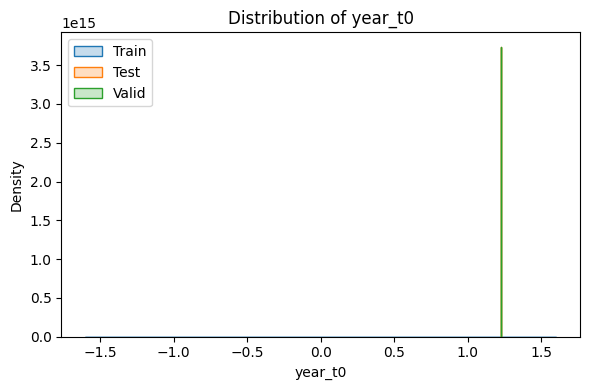

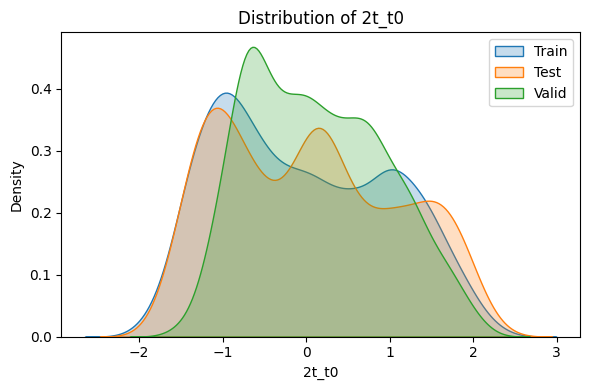

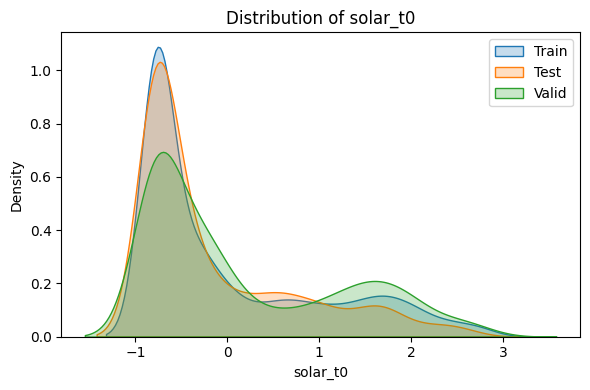

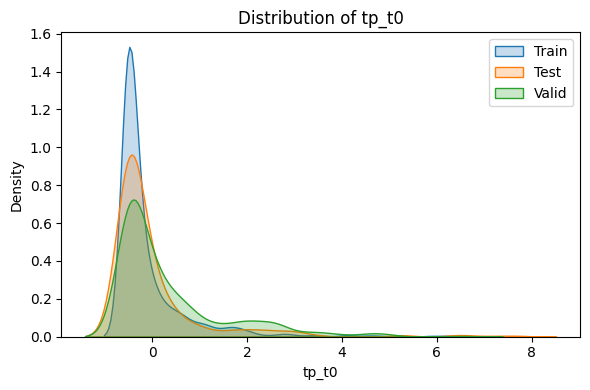

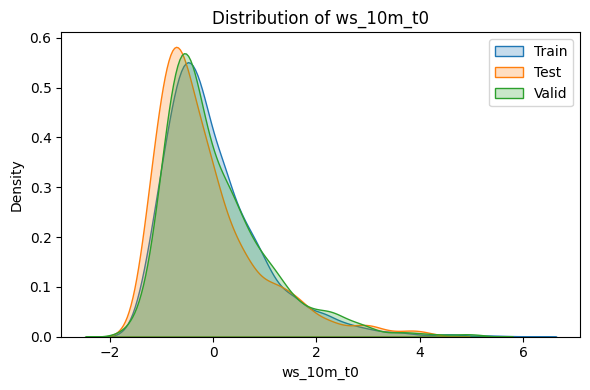

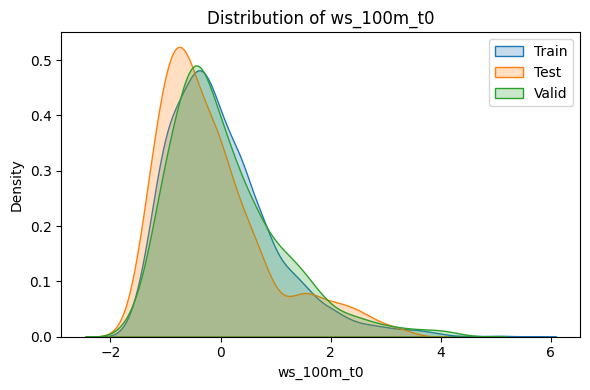

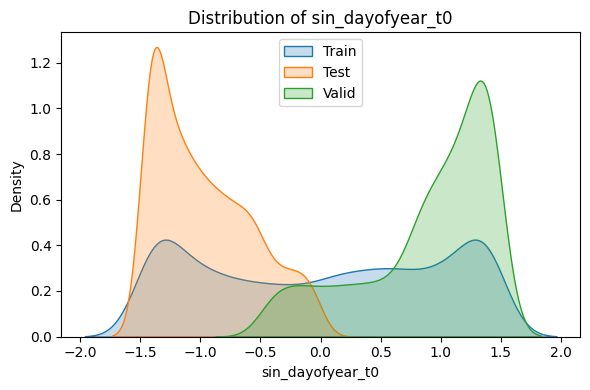

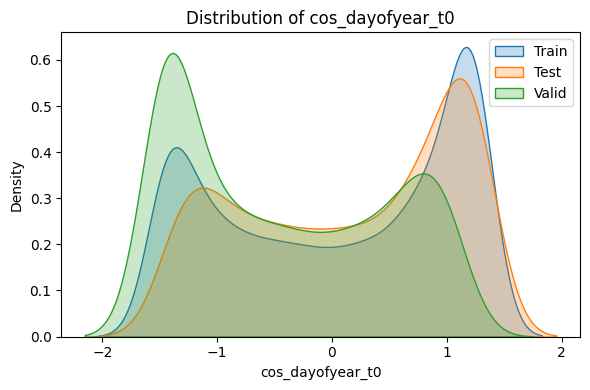

In [53]:
for column in train_features.columns:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(train_features[column], label='Train', fill=True)
    sns.kdeplot(test_features[column], label='Test', fill=True)
    sns.kdeplot(val_features[column], label = 'Valid', fill = True)
    plt.title(f'Distribution of {column}')
    plt.legend()
    plt.tight_layout()
    plt.show()